#解壓縮檔案 (unpack_and_prepare.py)

將 .tar.gz 解壓縮至指定檔案(.stdf)


In [ ]:
from google.colab import files
import gzip
import shutil
import tarfile
import os

# 1. 透過視窗上傳 .tar.gz 檔案
print("請選擇要上傳的 .tar.gz 檔案：")
uploaded = files.upload()

# 取得上傳檔案名稱
input_gz_path = list(uploaded.keys())[0]
print(f"已上傳檔案：{input_gz_path}")

# 2. 設定中繼與解壓路徑
intermediate_tar_path = '/content/temp_stdf.tar'
unpack_dir = '/content/unpacked'
os.makedirs(unpack_dir, exist_ok=True)

# 3. Step 1: 解壓 .gz 成 .tar
with gzip.open(input_gz_path, 'rb') as f_in, open(intermediate_tar_path, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
print(f"已解壓 .gz 為 .tar：{intermediate_tar_path}")

# 4. Step 2: 解開 .tar 至資料夾
with tarfile.open(intermediate_tar_path, 'r') as tar:
    tar.extractall(unpack_dir)
print(f"已將 .tar 解壓至資料夾：{unpack_dir}")

# 5. Step 3: 列出解壓後內容
print("解壓後內容：")
for filename in os.listdir(unpack_dir):
    print(" -", filename)

請選擇要上傳的 .tar.gz 檔案：


Saving main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF.tar.gz to main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF.tar.gz
已上傳檔案：main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF.tar.gz
已解壓 .gz 為 .tar：/content/temp_stdf.tar
已將 .tar 解壓至資料夾：/content/unpacked
解壓後內容：
 - main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF


# stdf_parser.py

對整⽀ STDF 檔案做全⾯解析，將所有記錄、所有欄位寫入 CSV。

In [ ]:
# 這是STDF檔案中各種記錄型態與子型態的對應字典，根據record_type與sub_type來標示記錄的名稱。
import struct
import csv

record_map = {
    (0, 10): "FAR",  # 檔案全域資訊 (Global information for the file)
    (0, 20): "ATR",  # 稽核軌跡紀錄 (Audit Trail Record)
    (1, 10): "MIR",  # 批次全域資訊 (Global information for entire lot)
    (1, 20): "MRR",  # 批次總結果摘要 (Master Results Record)
    (1, 30): "PCR",  # 零件總計數 (Part Count Record)
    (1, 40): "HBR",  # 硬體分類倉計數 (Hardware Bin Record)
    (1, 50): "SBR",  # 軟體分類倉計數 (Software Bin Record)
    (1, 60): "PMR",  # 多重參數測試結果記錄 (Parametric Multiple-Result Record)
    (1, 62): "PGR",  # 晶粒群組記錄 (Part Group Record)
    (1, 70): "RDR",  # 重測資料記錄 (Retest Data Record)
    (1, 80): "SDR",  # 測試摘要資料記錄 (Summary Data Record)
    (1, 91): "GDR",  # Bin 總數據記錄 (Gross Bin Data Record)
    (1, 92): "DTR",  # 裝置類型記錄 (Device Type Record)
    (2, 10): "WIR",  # 晶圓資訊 (Information for wafer)
    (2, 20): "WRR",  # 晶圓結果摘要 (Wafer Results Record)
    (2, 30): "WCR",  # 晶圓的尺寸和方向 (Dimensions and orientation of wafer)
    (5, 10): "PTR",  # 參數測試記錄 (Parametric Test Record)
    (5, 15): "PIR",  # 晶粒資訊 (Information for die)
    (5, 20): "PRR",  # 晶粒結果 (Part Results Record)
    (5, 30): "BPS",  # 參數分箱彙總記錄 (Bin Parameter Summary Record)
    (5, 40): "EPS",  # 例外參數彙總記錄 (Exception Parameter Summary Record)
    (10, 30): "TSR", # 測試摘要 (Test Synopsis Record)
    (15, 10): "FTR", # 功能測試記錄 (Functional Test Record)
    (15, 15): "MPR", # 主參數記錄 (Master Parametric Record)
}


In [ ]:
def parse_cn(data_segment, current_offset, current_endian=">"):
    """Parses a Cn (character string) field from a data segment."""

    if current_offset >= len(data_segment):
        return "", current_offset  # 如果 offset 超過資料長度，回傳空字串與原本的位置

    try:
        # 從目前位置讀取 1 byte，代表這個字串的長度
        # "B" = unsigned char (無號的 1 byte，值在 0~255 之間)
        length = struct.unpack(current_endian + "B", data_segment[current_offset:current_offset+1])[0]
        current_offset += 1  # 長度已讀，offset 往後移 1 byte

        end_offset = current_offset + length  # 計算字串資料的結束位置

        if end_offset > len(data_segment):
            # 如果字串長度超出資料長度，就抓剩下的所有資料
            val = data_segment[current_offset:].decode(errors="ignore")
            return val, len(data_segment)
        else:
            # 若長度合法，從 current_offset 開始讀 length 個 byte，轉成文字
            val = data_segment[current_offset:end_offset].decode(errors="ignore")
            return val, end_offset

    except Exception as e:
        return "", current_offset  # 若過程出錯，回傳空字串與原本 offset


解析 STDF 各種 record

In [ ]:
def parse_record(record_type, sub_type, data, current_endian):
    """Parses a specific STDF record based on its type and sub-type."""
    parsed = {"TYPE": record_map.get((record_type, sub_type), f"{record_type}:{sub_type}")}
    record_data_offset = 0 # Offset within the 'data' segment of the current record

    print(f"DEBUG: Parsing record (Type:{record_type}, SubType:{sub_type}) with {len(data)} bytes of data. Endianness: {current_endian}")

    try:
        # --- Type 0 (Information & Setup Records) ---
        if (record_type, sub_type) == (0, 10):  # FAR - File Attributes Record
            print(f"DEBUG FAR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 2:
                cpu_type = data[0]
                stdf_ver = data[1]
                parsed.update({
                    "CPU_TYPE": cpu_type,
                    "STDF_VER": stdf_ver
                })
            else:
                parsed["ERROR"] = f"FAR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (0, 20):  # ATR - Audit Trail Record
            print(f"DEBUG ATR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 4:
                mod_time = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG ATR: Parsed MOD_TIM, offset now {record_data_offset}")
                cmd_line, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG ATR: Parsed CMD_LINE, offset now {record_data_offset}")
                parsed.update({"MOD_TIM": mod_time, "CMD_LINE": cmd_line})
            else:
                parsed["ERROR"] = f"ATR record too short: {len(data)} bytes"
            return parsed

        # --- Type 1 (Part Count & Test Information Records) ---
        elif (record_type, sub_type) == (1, 10):  # MIR – Master Information Record
          print(f"DEBUG MIR: Data length {len(data)}, current offset {record_data_offset}")

          # 固定欄位最小長度：SETUP_T (4) + START_T (4) + STAT_NUM (1)
          # + MODE_COD (1) + RTST_COD (1) + PROT_COD (1)
          # + BURN_TIM (2) + CMOD_COD (1) + ARTC fields (28) = 43 bytes
          if len(data) < 43:
              parsed["ERROR"] = f"MIR record too short for fixed fields: {len(data)} bytes"
              return parsed

          # ▼ 解析 SETUP_T (U*4)
          tstamp = struct.unpack(current_endian + "I",
                                data[record_data_offset:record_data_offset+4])[0]
          record_data_offset += 4
          print(f"DEBUG MIR: Parsed SETUP_T={tstamp}, offset now {record_data_offset}")

          # ▼ 解析 START_T (U*4)
          cpgm_tim = struct.unpack(current_endian + "I",
                                  data[record_data_offset:record_data_offset+4])[0]
          record_data_offset += 4
          print(f"DEBUG MIR: Parsed START_T={cpgm_tim}, offset now {record_data_offset}")

          # ▼ 解析 STAT_NUM (U*1)
          stat_num = struct.unpack(current_endian + "B",
                                    data[record_data_offset:record_data_offset+1])[0]
          record_data_offset += 1
          print(f"DEBUG MIR: Parsed STAT_NUM={stat_num}, offset now {record_data_offset}")

          # ▼ 解析 MODE_COD, RTST_COD, PROT_COD, CMOD_COD (各 C*1，共 4 bytes)
          mode, rtstfl, prog_sf, rsrv_4 = struct.unpack(
              current_endian + "BBBB",
              data[record_data_offset:record_data_offset+4]
          )
          record_data_offset += 4
          print(f"DEBUG MIR: Parsed MODE={mode}, RTSTFL={rtstfl}, PROG_SF={prog_sf}, RSRV_4={rsrv_4}, offset now {record_data_offset}")

          # ▼ 解析 ARTC 固定欄位 (12 fields, 28 bytes)
          artc_fields_format = current_endian + "HHHHHIHHHHHI"
          artc_size = struct.calcsize(artc_fields_format)
          if record_data_offset + artc_size > len(data):
              parsed["ERROR"] = f"MIR record too short for ARTC fields: {len(data)} bytes"
              return parsed

          (artc_cnt, artc_res, artc_rst, artc_mod, artc_exm, artc_bin,
          artc_cnt_m, artc_rs_m, artc_rst_m, artc_mod_m, artc_exm_m, artc_bin_m) = \
              struct.unpack(
                  artc_fields_format,
                  data[record_data_offset:record_data_offset + artc_size]
              )
          record_data_offset += artc_size
          print(f"DEBUG MIR: Parsed ARTC fields, offset now {record_data_offset}")

          # ▼ 解析後續可變長 Cn 字串欄位
          sblot_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SBLOT_ID
          lot_id,   record_data_offset = parse_cn(data, record_data_offset, current_endian)  # LOT_ID
          part_typ, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # PART_TYP
          node_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # NODE_NAM
          tst_dev,  record_data_offset = parse_cn(data, record_data_offset, current_endian)  # TSTR_TYP
          job_nam,  record_data_offset = parse_cn(data, record_data_offset, current_endian)  # JOB_NAM
          job_rev,  record_data_offset = parse_cn(data, record_data_offset, current_endian)  # JOB_REV
          spu_id,   record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SPU_ID
          test_cod, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # TEST_COD
          tst_temp, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # TST_TEMP
          user_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # USER_TXT
          rsrv_30, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # AUX_FILE
          spec_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SPEC_NAM
          spec_ver, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SPEC_VER
          flow_id,  record_data_offset = parse_cn(data, record_data_offset, current_endian)  # FLOW_ID
          setup_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SETUP_ID
          dsgn_rev, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # DSGN_REV
          eng_id,   record_data_offset = parse_cn(data, record_data_offset, current_endian)  # ENG_ID
          rom_cod,  record_data_offset = parse_cn(data, record_data_offset, current_endian)  # ROM_COD
          serl_num, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SERL_NUM
          supr_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)  # SUPR_NAM

          # 最終更新 parsed 字典
          parsed.update({
              "TIME_STAMP": tstamp,
              "START_T":   cpgm_tim,
              "STAT_NUM":  stat_num,
              "MODE":      mode,
              "RTSTFL":    rtstfl,
              "PROG_SF":   prog_sf,
              "RSRV_4":    rsrv_4,
              "ARTC_CNT":  artc_cnt, "ARTC_RES": artc_res, "ARTC_RST":  artc_rst,
              "ARTC_MOD":  artc_mod, "ARTC_EXM": artc_exm, "ARTC_BIN":  artc_bin,
              "ARTC_CNT_M": artc_cnt_m, "ARTC_RS_M": artc_rs_m, "ARTC_RST_M": artc_rst_m,
              "ARTC_MOD_M": artc_mod_m, "ARTC_EXM_M": artc_exm_m, "ARTC_BIN_M": artc_bin_m,
              "SBLOT_ID":  sblot_id, "LOT_ID": lot_id,   "PART_TYP": part_typ,
              "NODE_NAM":  node_nam, "TSTR_TYP": tst_dev,"JOB_NAM":  job_nam,
              "JOB_REV":   job_rev,  "SPU_ID":   spu_id,  "TEST_COD": test_cod,
              "TST_TEMP":  tst_temp, "USER_TXT": user_txt,"RSRV_30": rsrv_30,
              "SPEC_NAM":  spec_nam, "SPEC_VER": spec_ver,"FLOW_ID":  flow_id,
              "SETUP_ID":  setup_id, "DSGN_REV": dsgn_rev,"ENG_ID":   eng_id,
              "ROM_COD":   rom_cod,  "SERL_NUM": serl_num,"SUPR_NAM": supr_nam,
          })
          return parsed

        elif (record_type, sub_type) == (1, 20):  # MRR - Master Results Record
          print(f"DEBUG MRR: Data length {len(data)}, current offset {record_data_offset}")

          # Helper：安全地 unpack 固定長度欄位
          def try_unpack(fmt, size, name):
              nonlocal record_data_offset
              if record_data_offset + size <= len(data):
                  val = struct.unpack(current_endian + fmt,
                                      data[record_data_offset:record_data_offset+size])[0]
                  record_data_offset += size
                  print(f"DEBUG MRR: Parsed {name} = {val}, offset now {record_data_offset}")
                  return val
              else:
                  print(f"DEBUG MRR: {name} not present ({len(data)-record_data_offset} bytes left)")
                  return None

          # Helper：安全地 parse Cn (長度前置字串)
          def try_parse_cn(field_name):
              nonlocal record_data_offset
              if record_data_offset < len(data):
                  val, new_off = parse_cn(data, record_data_offset, current_endian)
                  print(f"DEBUG MRR: Parsed {field_name} = '{val}', offset now {new_off}")
                  record_data_offset = new_off
                  return val
              else:
                  print(f"DEBUG MRR: {field_name} not present (no bytes left)")
                  return ""

          # 1. 固定欄位
          finish_t = try_unpack("I", 4, "FINISH_T")            # U*4
          # DISP_COD 是 1 byte ASCII
          disp_cod_val = try_unpack("B", 1, "DISP_COD")
          disp_cod = chr(disp_cod_val) if disp_cod_val is not None else ""
          print(f"DEBUG MRR: DISP_COD char = '{disp_cod}'")

          # 計數欄位，各 1 byte
          rtst_cnt = try_unpack("B", 1, "RTST_CNT")
          abrt_cnt = try_unpack("B", 1, "ABRT_CNT")
          good_cnt = try_unpack("B", 1, "GOOD_CNT")
          func_cnt = try_unpack("B", 1, "FUNC_CNT")

          # 2. 後續的長度可變字串欄位
          sblot_id = try_parse_cn("SBLOT_ID")
          lot_id   = try_parse_cn("LOT_ID")
          part_typ = try_parse_cn("PART_TYP")

          # 最後把所有欄位放入 parsed
          parsed.update({
              "FINISH_T": finish_t,
              "DISP_COD": disp_cod,
              "RTST_CNT": rtst_cnt,
              "ABRT_CNT": abrt_cnt,
              "GOOD_CNT": good_cnt,
              "FUNC_CNT": func_cnt,
              "SBLOT_ID": sblot_id,
              "LOT_ID": lot_id,
              "PART_TYP": part_typ,
          })
          return parsed


        elif (record_type, sub_type) == (1, 30):  # PCR - Part Count Record
            print(f"DEBUG PCR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 22: # 1+1+4*5 = 22 bytes
                head_num = data[record_data_offset]
                record_data_offset += 1
                print(f"DEBUG PCR: Parsed HEAD_NUM, offset now {record_data_offset}")
                site_num = data[record_data_offset]
                record_data_offset += 1
                print(f"DEBUG PCR: Parsed SITE_NUM, offset now {record_data_offset}")

                part_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG PCR: Parsed PART_CNT, offset now {record_data_offset}")
                retest_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG PCR: Parsed RETEST_CNT, offset now {record_data_offset}")
                abrt_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG PCR: Parsed ABRT_CNT, offset now {record_data_offset}")
                good_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG PCR: Parsed GOOD_CNT, offset now {record_data_offset}")
                func_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG PCR: Parsed FUNC_CNT, offset now {record_data_offset}")

                parsed.update({
                    "HEAD_NUM": head_num, "SITE_NUM": site_num, "PART_CNT": part_cnt,
                    "RETEST_CNT": retest_cnt, "ABRT_CNT": abrt_cnt, "GOOD_CNT": good_cnt, "FUNC_CNT": func_cnt
                })
            else:
                parsed["ERROR"] = f"PCR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (1, 40):  # HBR - Hardware Bin Record
            print(f"DEBUG HBR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 11: # 1+1+2+2+4+1 = 11 bytes minimum for fixed fields before Cn
                parsed["ERROR"] = f"HBR record too short for fixed fields: {len(data)} bytes"
                return parsed

            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG HBR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG HBR: Parsed SITE_NUM, offset now {record_data_offset}")
            hbr_nam = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG HBR: Parsed HBR_NAM, offset now {record_data_offset}")
            bin_num = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG HBR: Parsed BIN_NUM, offset now {record_data_offset}")
            bin_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG HBR: Parsed BIN_CNT, offset now {record_data_offset}")
            bin_pf = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG HBR: Parsed BIN_PF, offset now {record_data_offset}")

            scn_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian) # Optional Cn field
            print(f"DEBUG HBR: Parsed SCN_NAM '{scn_nam}', offset now {record_data_offset}")

            parsed.update({"HEAD_NUM": head_num, "SITE_NUM": site_num, "HBR_NAM": hbr_nam,
                           "BIN_NUM": bin_num, "BIN_CNT": bin_cnt, "BIN_PF": bin_pf,
                           "SCN_NAM": scn_nam})
            return parsed

        elif (record_type, sub_type) == (1, 50):  # SBR - Software Bin Record
          print(f"DEBUG SBR: Data length {len(data)}, current offset {record_data_offset}")
          # 固定欄位至少要 1+1+2+4+1 = 9 bytes 才能開始 Cn 欄位
          if len(data) < 9:
              parsed["ERROR"] = f"SBR record too short for fixed fields: {len(data)} bytes"
              return parsed

          # 1. HEAD_NUM (U1)
          head_num = data[record_data_offset]
          record_data_offset += 1
          print(f"DEBUG SBR: Parsed HEAD_NUM = {head_num}, offset now {record_data_offset}")

          # 2. SITE_NUM (U1)
          site_num = data[record_data_offset]
          record_data_offset += 1
          print(f"DEBUG SBR: Parsed SITE_NUM = {site_num}, offset now {record_data_offset}")

          # 3. SBR_NUM (U2)
          sbr_num = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
          record_data_offset += 2
          print(f"DEBUG SBR: Parsed SBR_NUM = {sbr_num}, offset now {record_data_offset}")

          # 4. SBR_CNT (U4)
          sbr_cnt = struct.unpack(current_endian + "I",
                                  data[record_data_offset:record_data_offset+4])[0]
          record_data_offset += 4
          print(f"DEBUG SBR: Parsed SBR_CNT = {sbr_cnt}, offset now {record_data_offset}")

          # 5. SBR_PF (B1)
          sbr_pf = data[record_data_offset]
          record_data_offset += 1
          print(f"DEBUG SBR: Parsed SBR_PF = {sbr_pf}, offset now {record_data_offset}")

          # 6. SBIN_NAM (C*n)
          sbin_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)
          print(f"DEBUG SBR: Parsed SBIN_NAM = '{sbin_nam}', offset now {record_data_offset}")

          # 更新 parsed dict
          parsed.update({
              "HEAD_NUM":  head_num,
              "SITE_NUM":  site_num,
              "SBR_NUM":   sbr_num,
              "SBR_CNT":   sbr_cnt,
              "SBR_PF":    sbr_pf,
              "SBIN_NAM":  sbin_nam
          })
          return parsed

        elif (record_type, sub_type) == (1, 60):  # PMR - Pin Map Record
          print(f"DEBUG PMR: Data length {len(data)}, current offset {record_data_offset}")

          # 1. PMR_INDX (U2)
          pmr_indx = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
          record_data_offset += 2
          print(f"DEBUG PMR: Parsed PMR_INDX = {pmr_indx}, offset now {record_data_offset}")

          # 2. CHAN_TYP (U2)
          chan_typ = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
          record_data_offset += 2
          print(f"DEBUG PMR: Parsed CHAN_TYP = {chan_typ}, offset now {record_data_offset}")

          # 【跳過 CHAN_NAM、PHY_NAM、LOG_NAM 的 C*n 資料】
          # 如果想要略過，可用前面的長度前綴直接跳過：
          # for _ in range(3):
          #     length = data[record_data_offset]
          #     record_data_offset += 1 + length

          # 3. HEAD_NUM (U1)
          head_num = data[record_data_offset]
          record_data_offset += 1
          print(f"DEBUG PMR: Parsed HEAD_NUM = {head_num}, offset now {record_data_offset}")

          # 4. SITE_NUM (U1)
          site_num = data[record_data_offset]
          record_data_offset += 1
          print(f"DEBUG PMR: Parsed SITE_NUM = {site_num}, offset now {record_data_offset}")

          parsed.update({
              "PMR_INDX": pmr_indx,
              "CHAN_TYP": chan_typ,
              "HEAD_NUM": head_num,
              "SITE_NUM": site_num
          })
          return parsed

        elif (record_type, sub_type) == (1, 62):  # PGR - Pin Group Record
          print(f"DEBUG PGR: Data length {len(data)}, current offset {record_data_offset}")

          # 1. GRP_INDX (U2)
          grp_indx = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
          record_data_offset += 2
          print(f"DEBUG PGR: Parsed GRP_INDX = {grp_indx}, offset now {record_data_offset}")

          # 2. 【跳過 GRP_NAM 的 C*n】
          # length = data[record_data_offset]
          # record_data_offset += 1 + length

          # 3. INDX_CNT (U2)
          indx_cnt = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
          record_data_offset += 2
          print(f"DEBUG PGR: Parsed INDX_CNT = {indx_cnt}, offset now {record_data_offset}")

          # 4. PMR_INDX 陣列 (U2 * INDX_CNT)
          pmr_list = []
          for i in range(indx_cnt):
              val = struct.unpack(current_endian + "H",
                                  data[record_data_offset:record_data_offset+2])[0]
              record_data_offset += 2
              pmr_list.append(val)
              print(f"DEBUG PGR: Parsed PMR_INDX[{i}] = {val}, offset now {record_data_offset}")

          parsed.update({
              "GRP_INDX": grp_indx,
              "INDX_CNT": indx_cnt,
              "PMR_INDX": pmr_list
          })
          return parsed

        elif (record_type, sub_type) == (1, 70):  # RDR - Retest Data Record
            print(f"DEBUG RDR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 2:
                num_bins = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
                record_data_offset += 2
                print(f"DEBUG RDR: Parsed NUM_BINS, offset now {record_data_offset}")
                rtst_bin = []
                for i in range(num_bins):
                    if record_data_offset + 2 <= len(data):
                        rtst_bin.append(struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0])
                        record_data_offset += 2
                    else:
                        print(f"DEBUG RDR: Truncated RTST_BIN array at index {i}")
                        break # Truncated array
                print(f"DEBUG RDR: Parsed RTST_BIN array, offset now {record_data_offset}")
                parsed.update({"NUM_BINS": num_bins, "RTST_BIN": rtst_bin})
            else:
                parsed["ERROR"] = f"RDR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (1, 80):  # SDR - Site Description Record
            print(f"DEBUG SDR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 3:
                head_num, site_grp, site_cnt = struct.unpack(current_endian + "BBB", data[record_data_offset:record_data_offset+3])
                record_data_offset += 3
                print(f"DEBUG SDR: Parsed HEAD_NUM, SITE_GRP, SITE_CNT, offset now {record_data_offset}")
                site_nums = []
                for i in range(site_cnt):
                    if record_data_offset + 1 <= len(data):
                        site_nums.append(data[record_data_offset])
                        record_data_offset += 1
                    else:
                        print(f"DEBUG SDR: Truncated SITE_NUM array at index {i}")
                        break # Truncated array
                print(f"DEBUG SDR: Parsed SITE_NUM array, offset now {record_data_offset}")
                parsed.update({"HEAD_NUM": head_num, "SITE_GRP": site_grp, "SITE_CNT": site_cnt, "SITE_NUM": site_nums})
            else:
                parsed["ERROR"] = f"SDR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (1, 91):  # GDR - Generic Data Record
            print(f"DEBUG GDR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 2:
                field_count = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
                record_data_offset += 2
                print(f"DEBUG GDR: Parsed FLD_CNT, offset now {record_data_offset}")
                parsed.update({"GENERIC_FIELD_COUNT": field_count, "INFO": "Generic Data Record (data not parsed)"})
            else:
                parsed["ERROR"] = f"GDR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (1, 92):  # DTR - Datalog Text Record
            print(f"DEBUG DTR: Data length {len(data)}, current offset {record_data_offset}")
            d_text, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG DTR: Parsed TEXT_DAT '{d_text}', offset now {record_data_offset}")
            parsed.update({"DATALOG_TEXT": d_text})
            return parsed

        # --- Type 2 (Wafer & Die Records) ---
        elif (record_type, sub_type) == (2, 10):  # WIR - Wafer Information Record
            print(f"DEBUG WIR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 6: # U1+U1+U4 = 6 bytes minimum before Cn
                parsed["ERROR"] = f"WIR record too short for fixed fields: {len(data)} bytes"
                return parsed

            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG WIR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_grp = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG WIR: Parsed SITE_GRP, offset now {record_data_offset}")
            start_t = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WIR: Parsed START_T, offset now {record_data_offset}")

            wafer_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG WIR: Parsed WAFER_ID '{wafer_id}', offset now {record_data_offset}")
            parsed.update({"HEAD_NUM": head_num, "SITE_GRP": site_grp, "START_T": start_t, "WAFER_ID": wafer_id})
            return parsed

        elif (record_type, sub_type) == (2, 20):  # WRR - Wafer Results Record
            print(f"DEBUG WRR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 26: # 1+1+4*6 = 26 bytes minimum for fixed fields before Cn
                parsed["ERROR"] = f"WRR record too short for fixed fields: {len(data)} bytes"
                return parsed

            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG WRR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_grp = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG WRR: Parsed SITE_GRP, offset now {record_data_offset}")
            finish_t = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed FINISH_T, offset now {record_data_offset}")
            part_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed PART_CNT, offset now {record_data_offset}")
            rtst_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed RTST_CNT, offset now {record_data_offset}")
            abrt_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed ABRT_CNT, offset now {record_data_offset}")
            good_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed GOOD_CNT, offset now {record_data_offset}")
            func_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WRR: Parsed FUNC_CNT, offset now {record_data_offset}")

            wafer_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG WRR: Parsed WAFER_ID '{wafer_id}', offset now {record_data_offset}")

            parsed.update({
                "HEAD_NUM": head_num, "SITE_GRP": site_grp, "FINISH_T": finish_t, "PART_CNT": part_cnt,
                "RTST_CNT": rtst_cnt, "ABRT_CNT": abrt_cnt, "GOOD_CNT": good_cnt, "FUNC_CNT": func_cnt,
                "WAFER_ID": wafer_id
            })
            return parsed

        elif (record_type, sub_type) == (2, 30):  # WCR - Wafer Configuration Record
            print(f"DEBUG WCR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 20: # 4*3 + 1*2 + 2*2 + 1*2 = 20 bytes
                parsed["ERROR"] = f"WCR record too short: {len(data)} bytes"
                return parsed

            wafr_siz = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WCR: Parsed WAFR_SIZ, offset now {record_data_offset}")
            die_ht = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WCR: Parsed DIE_HT, offset now {record_data_offset}")
            die_wid = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG WCR: Parsed DIE_WID, offset now {record_data_offset}")
            wf_units = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG WCR: Parsed WF_UNITS, offset now {record_data_offset}")
            wf_flat = chr(data[record_data_offset])
            record_data_offset += 1
            print(f"DEBUG WCR: Parsed WF_FLAT, offset now {record_data_offset}")
            center_x = struct.unpack(current_endian + "h", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG WCR: Parsed CENTER_X, offset now {record_data_offset}")
            center_y = struct.unpack(current_endian + "h", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG WCR: Parsed CENTER_Y, offset now {record_data_offset}")
            pos_x = chr(data[record_data_offset])
            record_data_offset += 1
            print(f"DEBUG WCR: Parsed POS_X, offset now {record_data_offset}")
            pos_y = chr(data[record_data_offset])
            record_data_offset += 1
            print(f"DEBUG WCR: Parsed POS_Y, offset now {record_data_offset}")

            parsed.update({
                "WAFR_SIZ": wafr_siz, "DIE_HT": die_ht, "DIE_WID": die_wid, "WF_UNITS": wf_units,
                "WF_FLAT": wf_flat, "CENTER_X": center_x, "CENTER_Y": center_y, "POS_X": pos_x, "POS_Y": pos_y
            })
            return parsed

        elif (record_type, sub_type) == (5, 10):  # PTR - Parametric Test Record
          print(f"DEBUG PTR: Data length {len(data)}, current offset {record_data_offset}")

          # 小 helper：unpack 固定長度欄位
          def try_unpack(fmt, size, name):
              nonlocal record_data_offset
              if record_data_offset + size <= len(data):
                  val = struct.unpack(current_endian + fmt,
                                      data[record_data_offset:record_data_offset+size])[0]
                  record_data_offset += size
                  print(f"DEBUG PTR: Parsed {name} = {val}, offset now {record_data_offset}")
                  return val
              else:
                  print(f"DEBUG PTR: {name} not present ({len(data)-record_data_offset} bytes left)")
                  return None

          # 小 helper：parse Cn（字串）欄位
          def try_parse_cn(field_name):
              nonlocal record_data_offset
              if record_data_offset < len(data):
                  val, new_off = parse_cn(data, record_data_offset, current_endian)
                  print(f"DEBUG PTR: Parsed {field_name} = '{val}', offset now {new_off}")
                  record_data_offset = new_off
                  return val
              else:
                  print(f"DEBUG PTR: {field_name} not present (no bytes left)")
                  return ""

          # 1. 固定欄位
          test_num  = try_unpack("I", 4, "TEST_NUM")
          head_num  = try_unpack("B", 1, "HEAD_NUM")
          site_num  = try_unpack("B", 1, "SITE_NUM")
          test_flg  = try_unpack("B", 1, "TEST_FLG")
          parm_flg  = try_unpack("B", 1, "PARM_FLG")
          result    = try_unpack("f", 4, "RESULT")

          # 2. 圖中列出的 C*n 欄位
          test_txt  = try_parse_cn("TEST_TXT")
          alarm_id  = try_parse_cn("ALARM_ID")

          # 3. 可選數值欄位（OPT_FLAG 控制，但我們不深入 bit 了，只要能讀就讀）
          opt_flag  = try_unpack("B", 1, "OPT_FLAG")
          res_scal  = try_unpack("b", 1, "RES_SCAL")
          llm_scal  = try_unpack("b", 1, "LLM_SCAL")
          hlm_scal  = try_unpack("b", 1, "HLM_SCAL")

          # 4. 上／下限值
          lo_limit  = try_unpack("f", 4, "LO_LIMIT")
          hi_limit  = try_unpack("f", 4, "HI_LIMIT")

          # 5. 圖中剩下的格式與規格字串欄位
          units     = try_parse_cn("UNITS")
          c_resfmt  = try_parse_cn("C_RESFMT")
          c_llmfmt  = try_parse_cn("C_LLMFMT")
          c_hlmfmt  = try_parse_cn("C_HLFMFT")

          # 6. 最後的規格上下限
          lo_spec   = try_unpack("f", 4, "LO_SPEC")
          hi_spec   = try_unpack("f", 4, "HI_SPEC")

          # 組回傳 dict
          parsed.update({
              "TEST_NUM":   test_num,  "HEAD_NUM":  head_num,  "SITE_NUM":  site_num,
              "TEST_FLG":   test_flg,  "PARM_FLG":  parm_flg,  "RESULT":    result,
              "TEST_TXT":   test_txt,  "ALARM_ID":  alarm_id,
              "OPT_FLAG":   opt_flag,  "RES_SCAL":  res_scal,  "LLM_SCAL":   llm_scal,
              "HLM_SCAL":   hlm_scal,  "LO_LIMIT":  lo_limit,  "HI_LIMIT":   hi_limit,
              "UNITS":      units,     "C_RESFMT":  c_resfmt,  "C_LLMFMT":   c_llmfmt,
              "C_HLFMFT":   c_hlmfmt,  "LO_SPEC":   lo_spec,   "HI_SPEC":    hi_spec
          })
          return parsed



        elif (record_type, sub_type) == (5, 15):  # PIR - Part Information Record
            print(f"DEBUG PIR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) >= 2:
                head_num = data[record_data_offset]
                record_data_offset += 1
                print(f"DEBUG PIR: Parsed HEAD_NUM, offset now {record_data_offset}")
                site_num = data[record_data_offset]
                record_data_offset += 1
                print(f"DEBUG PIR: Parsed SITE_NUM, offset now {record_data_offset}")
                parsed.update({"HEAD_NUM": head_num, "SITE_NUM": site_num})
            else:
                parsed["ERROR"] = f"PIR record too short: {len(data)} bytes"
            return parsed

        elif (record_type, sub_type) == (5, 20):  # PRR - Part Results Record
            print(f"DEBUG PRR: Data length {len(data)}, current offset {record_data_offset}")
            # 固定欄位長度：1+1+1+2+2+2+2+2+4 = 17 bytes
            if len(data) < 17:
                parsed["ERROR"] = f"PRR record too short for fixed fields: {len(data)} bytes"
                return parsed

            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG PRR: Parsed HEAD_NUM, offset now {record_data_offset}")

            site_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG PRR: Parsed SITE_NUM, offset now {record_data_offset}")

            part_flg = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG PRR: Parsed PART_FLG, offset now {record_data_offset}")

            # NUM_TEST 應為 2 bytes 的 U*2
            num_test = struct.unpack(current_endian + "H",
                                    data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG PRR: Parsed NUM_TEST, offset now {record_data_offset}")

            hard_bin = struct.unpack(current_endian + "H",
                                    data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG PRR: Parsed HARD_BIN, offset now {record_data_offset}")

            soft_bin = struct.unpack(current_endian + "H",
                                    data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG PRR: Parsed SOFT_BIN, offset now {record_data_offset}")

            x_coord = struct.unpack(current_endian + "h",
                                    data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG PRR: Parsed X_COORD, offset now {record_data_offset}")

            y_coord = struct.unpack(current_endian + "h",
                                    data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG PRR: Parsed Y_COORD, offset now {record_data_offset}")

            test_t = struct.unpack(current_endian + "I",
                                    data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG PRR: Parsed TEST_T, offset now {record_data_offset}")

            # Cn fields
            part_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG PRR: Parsed PART_ID '{part_id}', offset now {record_data_offset}")
            part_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG PRR: Parsed PART_TXT '{part_txt}', offset now {record_data_offset}")
            part_fix, record_data_offset = parse_cn(data, record_data_offset, current_endian)
            print(f"DEBUG PRR: Parsed PART_FIX '{part_fix}', offset now {record_data_offset}")

            parsed.update({
                "HEAD_NUM": head_num, "SITE_NUM": site_num, "PART_FLG": part_flg,
                "NUM_TEST": num_test, "HARD_BIN": hard_bin, "SOFT_BIN": soft_bin,
                "X_COORD": x_coord, "Y_COORD": y_coord, "TEST_T": test_t,
                "PART_ID": part_id, "PART_TXT": part_txt, "PART_FIX": part_fix
            })
            return parsed


        elif (record_type, sub_type) == (5, 30):  # BPS - Begin Program Section
            print(f"DEBUG BPS: Data length {len(data)}, current offset {record_data_offset}")
            parsed.update({"INFO": "Begin Program Section"})
            return parsed

        elif (record_type, sub_type) == (5, 40):  # EPS - End Program Section
            print(f"DEBUG EPS: Data length {len(data)}, current offset {record_data_offset}")
            parsed.update({"INFO": "End Program Section"})
            return parsed

        # --- Type 10 (Test & Result Records) ---
        elif (record_type, sub_type) == (10, 30):  # TSR - Test Summary Record
            print(f"DEBUG TSR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 19: # Fixed fields: 1+1+1+4+4+4+4 = 19 bytes
                parsed["ERROR"] = f"TSR record too short: {len(data)} bytes"
                return parsed

            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG TSR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG TSR: Parsed SITE_NUM, offset now {record_data_offset}")
            test_typ = chr(data[record_data_offset]) # C1
            record_data_offset += 1
            print(f"DEBUG TSR: Parsed TEST_TYP, offset now {record_data_offset}")
            test_num = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG TSR: Parsed TEST_NUM, offset now {record_data_offset}")
            exec_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG TSR: Parsed EXEC_CNT, offset now {record_data_offset}")
            fail_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG TSR: Parsed FAIL_CNT, offset now {record_data_offset}")
            alarm_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG TSR: Parsed ALARM_CNT, offset now {record_data_offset}")
            rsrv_3 = chr(data[record_data_offset]) # C1 (Reserved)
            record_data_offset += 1
            print(f"DEBUG TSR: Parsed RSRV_3, offset now {record_data_offset}")


            test_nam = ""
            if record_data_offset < len(data):
                test_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed TEST_NAM '{test_nam}', offset now {record_data_offset}")

            seq_nam = ""
            if record_data_offset < len(data):
                seq_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed SEQ_NAM '{seq_nam}', offset now {record_data_offset}")

            test_lbl = ""
            if record_data_offset < len(data):
                test_lbl, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed TEST_LBL '{test_lbl}', offset now {record_data_offset}")

            test_txt = ""
            if record_data_offset < len(data):
                test_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed TEST_TXT '{test_txt}', offset now {record_data_offset}")

            alarm_id = ""
            if record_data_offset < len(data):
                alarm_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed ALARM_ID '{alarm_id}', offset now {record_data_offset}")

            opt_flag = None
            if record_data_offset + 1 <= len(data):
                opt_flag = data[record_data_offset] # B1
                record_data_offset += 1
                print(f"DEBUG TSR: Parsed OPT_FLAG, offset now {record_data_offset}")

            res_scal = None
            if record_data_offset + 1 <= len(data):
                res_scal = struct.unpack(current_endian + "b", data[record_data_offset:record_data_offset+1])[0] # I1 (signed char)
                record_data_offset += 1
                print(f"DEBUG TSR: Parsed RES_SCAL, offset now {record_data_offset}")

            llm_scal = None
            if record_data_offset + 1 <= len(data):
                llm_scal = struct.unpack(current_endian + "b", data[record_data_offset:record_data_offset+1])[0]
                record_data_offset += 1
                print(f"DEBUG TSR: Parsed LLM_SCAL, offset now {record_data_offset}")

            hl_scal = None
            if record_data_offset + 1 <= len(data):
                hl_scal = struct.unpack(current_endian + "b", data[record_data_offset:record_data_offset+1])[0]
                record_data_offset += 1
                print(f"DEBUG TSR: Parsed HL_SCAL, offset now {record_data_offset}")

            lo_limit = None
            if record_data_offset + 4 <= len(data):
                lo_limit = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG TSR: Parsed LO_LIMIT, offset now {record_data_offset}")

            hi_limit = None
            if record_data_offset + 4 <= len(data):
                hi_limit = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG TSR: Parsed HI_LIMIT, offset now {record_data_offset}")

            units = ""
            if record_data_offset < len(data):
                units, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed UNITS '{units}', offset now {record_data_offset}")

            c_resfmt = ""
            if record_data_offset < len(data):
                c_resfmt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed C_RESFMT '{c_resfmt}', offset now {record_data_offset}")

            c_unitfmt = ""
            if record_data_offset < len(data):
                c_unitfmt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG TSR: Parsed C_UNITFMT '{c_unitfmt}', offset now {record_data_offset}")

            lo_spec = None
            if record_data_offset + 4 <= len(data):
                lo_spec = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG TSR: Parsed LO_SPEC, offset now {record_data_offset}")

            hi_spec = None
            if record_data_offset + 4 <= len(data):
                hi_spec = struct.unpack(current_endian + "f", data[record_data_offset:record_data_offset+4])[0]
                record_data_offset += 4
                print(f"DEBUG TSR: Parsed HI_SPEC, offset now {record_data_offset}")


            parsed.update({
                "HEAD_NUM": head_num, "SITE_NUM": site_num, "TEST_TYP": test_typ, "TEST_NUM": test_num,
                "EXEC_CNT": exec_cnt, "FAIL_CNT": fail_cnt, "ALARM_CNT": alarm_cnt, "RSRV_3": rsrv_3,
                "TEST_NAM": test_nam, "SEQ_NAM": seq_nam, "TEST_LBL": test_lbl, "TEST_TXT": test_txt,
                "ALARM_ID": alarm_id, "OPT_FLAG": opt_flag, "RES_SCAL": res_scal, "LLM_SCAL": llm_scal,
                "HL_SCAL": hl_scal, "LO_LIMIT": lo_limit, "HI_LIMIT": hi_limit, "UNITS": units,
                "C_RESFMT": c_resfmt, "C_UNITFMT": c_unitfmt, "LO_SPEC": lo_spec, "HI_SPEC": hi_spec
            })
            return parsed

        # --- Type 15 (Test & Result Records) ---
        elif (record_type, sub_type) == (15, 10):  # FTR - Functional Test Record
            print(f"DEBUG FTR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 22: # Min fixed fields: U4+U1+U1+B1+B1+U4+U4+U4 = 22 bytes
                parsed["ERROR"] = f"FTR record too short for fixed fields: {len(data)} bytes"
                return parsed

            test_num = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG FTR: Parsed TEST_NUM, offset now {record_data_offset}")
            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG FTR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG FTR: Parsed SITE_NUM, offset now {record_data_offset}")
            test_flg = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG FTR: Parsed TEST_FLG, offset now {record_data_offset}")
            op_flg = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG FTR: Parsed OP_FLG, offset now {record_data_offset}")
            cycl_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG FTR: Parsed CYCL_CNT, offset now {record_data_offset}")
            fail_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG FTR: Parsed FAIL_CNT, offset now {record_data_offset}")
            alarm_cnt = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG FTR: Parsed ALARM_CNT, offset now {record_data_offset}")

            test_nam = ""
            if record_data_offset < len(data):
                test_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed TEST_NAM '{test_nam}', offset now {record_data_offset}")

            seq_nam = ""
            if record_data_offset < len(data):
                seq_nam, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed SEQ_NAM '{seq_nam}', offset now {record_data_offset}")

            test_txt = ""
            if record_data_offset < len(data):
                test_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed TEST_TXT '{test_txt}', offset now {record_data_offset}")

            alarm_id = ""
            if record_data_offset < len(data):
                alarm_id, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed ALARM_ID '{alarm_id}', offset now {record_data_offset}")

            prog_txt = ""
            if record_data_offset < len(data):
                prog_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed PROG_TXT '{prog_txt}', offset now {record_data_offset}")

            rslt_txt = ""
            if record_data_offset < len(data):
                rslt_txt, record_data_offset = parse_cn(data, record_data_offset, current_endian)
                print(f"DEBUG FTR: Parsed RSLT_TXT '{rslt_txt}', offset now {record_data_offset}")

            parsed.update({
                "TEST_NUM": test_num, "HEAD_NUM": head_num, "SITE_NUM": site_num,
                "TEST_FLG": test_flg, "OP_FLG": op_flg, "CYCL_CNT": cycl_cnt,
                "FAIL_CNT": fail_cnt, "ALARM_CNT": alarm_cnt,
                "TEST_NAM": test_nam, "SEQ_NAM": seq_nam, "TEST_TXT": test_txt,
                "ALARM_ID": alarm_id, "PROG_TXT": prog_txt, "RSLT_TXT": rslt_txt
            })
            return parsed

        elif (record_type, sub_type) == (15, 15):  # MPR - Multiple Pin Result
            print(f"DEBUG MPR: Data length {len(data)}, current offset {record_data_offset}")
            if len(data) < 12: # Min fixed fields for your current implementation (U4+U1+U1+B1+B1+U2+U2)
                parsed["ERROR"] = f"MPR record too short: {len(data)} bytes"
                return parsed

            test_num = struct.unpack(current_endian + "I", data[record_data_offset:record_data_offset+4])[0]
            record_data_offset += 4
            print(f"DEBUG MPR: Parsed TEST_NUM, offset now {record_data_offset}")
            head_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG MPR: Parsed HEAD_NUM, offset now {record_data_offset}")
            site_num = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG MPR: Parsed SITE_NUM, offset now {record_data_offset}")
            test_flg = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG MPR: Parsed TEST_FLG, offset now {record_data_offset}")
            parm_flg = data[record_data_offset]
            record_data_offset += 1
            print(f"DEBUG MPR: Parsed PARM_FLG, offset now {record_data_offset}")
            rtn_cnt = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG MPR: Parsed RTN_CNT, offset now {record_data_offset}")
            rslt_cnt = struct.unpack(current_endian + "H", data[record_data_offset:record_data_offset+2])[0]
            record_data_offset += 2
            print(f"DEBUG MPR: Parsed RSLT_CNT, offset now {record_data_offset}")

            parsed.update({
                "TEST_NUM": test_num, "HEAD_NUM": head_num, "SITE_NUM": site_num,
                "TEST_FLG": test_flg, "PARM_FLG": parm_flg,
                "RTN_CNT": rtn_cnt, "RSLT_CNT": rslt_cnt
            })
            return parsed

        # Fallback for unimplemented or unrecognized records
        print(f"DEBUG: Record type ({record_type},{sub_type}) is implemented partially or not fully parsed yet. Remaining data length: {len(data) - record_data_offset}")
        parsed["NOTE"] = f"Record type ({record_type},{sub_type}) implemented partially or not fully parsed. Raw Data Hex: {data[record_data_offset:].hex()}"

    except Exception as e:
        print(f"Error parsing ({record_type},{sub_type}) - {record_map.get((record_type, sub_type), 'Unknown')} - {e}")
        print(f"  --> Failed at record_data_offset: {record_data_offset}/{len(data)}")
        print(f"  --> Raw Data (hex): {data.hex()}")
        parsed["ERROR"] = str(e)
        parsed["FULL_DATA_HEX"] = data.hex()
        parsed["PARSED_UP_TO_OFFSET_IN_RECORD"] = record_data_offset

    return parsed

def parse_stdf(filepath, output_csv):
    with open(filepath, "rb") as f:
        binary = f.read()

    offset = 0
    parsed_rows = []
    all_fields = set()
    current_file_endian = ">" # Default to Big-Endian

    print(f"開始解析 STDF 檔案: {filepath}")

    # Special handling for FAR (File Attributes Record) to determine endianness
    # FAR is always the first record in a valid STDF file.
    if len(binary) >= 4:
        # Attempt to read FAR header with both Big-Endian and Little-Endian to see which is valid
        # We need to consider that the 'reclen' itself is affected by endianness.
        reclen_be, rectype_be, recsub_be = (0,0,0)
        reclen_le, rectype_le, recsub_le = (0,0,0)

        try:
            reclen_be, rectype_be, recsub_be = struct.unpack(">HBB", binary[0:4])
        except struct.error:
            pass # Not enough data or other issue for Big-Endian unpack

        try:
            reclen_le, rectype_le, recsub_le = struct.unpack("<HBB", binary[0:4])
        except struct.error:
            pass # Not enough data or other issue for Little-Endian unpack

        # Prioritize Little-Endian if it results in a FAR record with a small, valid length
        # A FAR record typically has a data length of 2 bytes (CPU_TYPE, STDF_VER).
        if rectype_le == 0 and recsub_le == 10 and reclen_le == 2:
            current_file_endian = "<"
            print("檢測到 STDF 檔案為 Little-Endian (小端模式).")
            # Now, parse the FAR using the determined Little-Endian
            far_data = binary[4 : 4 + reclen_le]
            far_parsed = parse_record(rectype_le, recsub_le, far_data, current_file_endian)
            parsed_rows.append(far_parsed)
            all_fields.update(far_parsed.keys())
            offset = 4 + reclen_le # Move offset past FAR

        # If Little-Endian wasn't a perfect match for FAR(0,10) with reclen=2,
        # then check if Big-Endian provides a valid FAR.
        # It's less likely if the initial error was reclen 12590, but worth checking for robustness.
        elif rectype_be == 0 and recsub_be == 10 and reclen_be == 2:
            current_file_endian = ">"
            print("檢測到 STDF 檔案為 Big-Endian (大端模式).")
            # Parse FAR using Big-Endian
            far_data = binary[4 : 4 + reclen_be]
            far_parsed = parse_record(rectype_be, recsub_be, far_data, current_file_endian)
            parsed_rows.append(far_parsed)
            all_fields.update(far_parsed.keys())
            offset = 4 + reclen_be # Move offset past FAR
        else:
            # If neither attempts yield a standard FAR(0,10) with reclen=2,
            # fall back to default Big-Endian and let the main loop attempt parsing.
            # This might happen if the file is truly odd or corrupted at the very beginning.
            print(f"第一個記錄不是標準 FAR(0,10) 且 reclen=2。預設為 Big-Endian。")
            print(f"   BE 嘗試: reclen={reclen_be}, type={rectype_be}, sub={recsub_be}")
            print(f"   LE 嘗試: reclen={reclen_le}, type={rectype_le}, sub={recsub_le}")

    else:
        print("檔案太短，無法讀取第一個記錄頭。")

    # Main loop for parsing all records
    while offset + 4 <= len(binary):
        try:
            # Use the determined endianness for all subsequent record headers
            # print(f"DEBUG: Reading next record header at offset {offset} with endianness '{current_file_endian}'")
            reclen, rectype, recsub = struct.unpack(current_file_endian + "HBB", binary[offset:offset+4])

            record_start_offset = offset

            # Basic sanity check for reclen to prevent reading beyond file
            if reclen < 0 or offset + 4 + reclen > len(binary):
                print(f"警告: 無效的記錄長度 {reclen} 或超出檔案範圍，於偏移量 {record_start_offset}。停止解析。")
                print(f"  --> 檔案總長度: {len(binary)} bytes. 預計讀取到: {offset + 4 + reclen}")
                # Optional: dump raw bytes around the error for manual inspection
                # print(f"  --> Data around error (hex): {binary[max(0, record_start_offset-10):min(len(binary), record_start_offset+10+4+reclen)].hex()}")
                break

            print(f"--- 讀取記錄頭: Type={rectype}, SubType={recsub}, Length={reclen} (Start Offset: {record_start_offset}) ---")

            offset += 4 # Move past header
            data = binary[offset:offset+reclen]
            offset += reclen # Move past data to next record header

            parsed = parse_record(rectype, recsub, data, current_file_endian)
            parsed_rows.append(parsed)
            all_fields.update(parsed.keys())
            print(f"成功解析記錄: TYPE={record_map.get((rectype, recsub), f'{rectype}:{recsub}')} (實際長度: {4 + reclen} bytes) at offset {record_start_offset}. Next record starts at {offset}")

        except struct.error as se:
            print(f"struct 解包錯誤於偏移量 {offset}，可能位元組順序或資料損壞: {se}")
            # Try to dump raw bytes around the error
            error_data_start = max(0, offset - 10)
            error_data_end = min(len(binary), offset + 10)
            print(f"  --> Data around error (hex): {binary[error_data_start:error_data_end].hex()}")
            break
        except IndexError as ie:
            print(f"讀取資料超出檔案範圍於偏移量 {offset}，可能記錄長度有誤: {ie}")
            # Try to dump raw bytes around the error
            error_data_start = max(0, offset - 10)
            error_data_end = min(len(binary), offset + 10)
            print(f"  --> Data around error (hex): {binary[error_data_start:error_data_end].hex()}")
            break
        except Exception as e:
            print(f"泛型錯誤於偏移量 {offset}: {e}")
            # Try to dump raw bytes around the error
            error_data_start = max(0, offset - 10)
            error_data_end = min(len(binary), offset + 10)
            print(f"  --> Data around error (hex): {binary[error_data_start:error_data_end].hex()}")
            break

    # Write parsed data to CSV
    all_fields = sorted(list(all_fields))
    with open(output_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=all_fields)
        writer.writeheader()
        for row in parsed_rows:
            cleaned_row = {k: v for k, v in row.items() if k in all_fields}
            writer.writerow(cleaned_row)

    print(f"解析完成，共 {len(parsed_rows)} 筆記錄，輸出為 {output_csv}")


In [ ]:
import os

# 啟用 Colab 自動下載
try:
    from google.colab import files
    download_fn = files.download
except ImportError:
    download_fn = lambda path: print(f"[完成] 已生成：{path}")

# 1. 建立 output 資料夾（相對路徑）
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)
print(f"已建立資料夾：{output_dir}")

# 2. 掃描 unpacked 資料夾（相對路徑）
unpack_dir = 'unpacked'
print("將從資料夾解析所有檔案：", unpack_dir)
for name in os.listdir(unpack_dir):
    in_path = os.path.join(unpack_dir, name)
    if not os.path.isfile(in_path):
        continue
    # 3. 設定輸出 CSV 路徑
    csv_name = f"{os.path.splitext(name)[0]}.csv"
    out_path = os.path.join(output_dir, csv_name)
    # 4. 呼叫解析函式（需先定義 parse_stdf）
    parse_stdf(in_path, out_path)
    print(f"已輸出 CSV：{out_path}")
    # 5. 自動下載 CSV
    download_fn(out_path)


已建立資料夾：output
將從資料夾解析所有檔案： unpacked
⌛️ 開始解析 STDF 檔案: unpacked/main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF
檢測到 STDF 檔案為 Little-Endian (小端模式).
DEBUG: Parsing record (Type:0, SubType:10) with 2 bytes of data. Endianness: <
DEBUG FAR: Data length 2, current offset 0
--- 讀取記錄頭: Type=0, SubType=20, Length=121 (Start Offset: 6) ---
DEBUG: Parsing record (Type:0, SubType:20) with 121 bytes of data. Endianness: <
DEBUG ATR: Data length 121, current offset 0
DEBUG ATR: Parsed MOD_TIM, offset now 4
DEBUG ATR: Parsed CMD_LINE, offset now 121
成功解析記錄: TYPE=ATR (實際長度: 125 bytes) at offset 6. Next record starts at 131
--- 讀取記錄頭: Type=1, SubType=10, Length=130 (Start Offset: 131) ---
DEBUG: Parsing record (Type:1, SubType:10) with 130 bytes of data. Endianness: <
DEBUG MIR: Data length 130, current offset 0
DEBUG MIR: Parsed SETUP_T=1476351210, offset now 4
DEBUG MIR: Parsed START_T=1476351224, offset now 8
DEBUG MIR: Parsed STAT_NUM=1, offset now 9
DEBUG MIR: Parsed MODE=32, RTSTFL=78, PROG_SF=32, RSRV_4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# extract_prr.py

專門抓取 PRR (Part Results Record) 記錄中的 X、Y 座標與 PART\_ID，輸出簡易 CSV。

In [ ]:
import os
import struct
import csv

# Colab 下載 helper
try:
    from google.colab import files
    download = files.download
except ImportError:
    download = lambda path: print(f"[CSV Ready] {path}")

# 建立 output 資料夾
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)
print(f"Output 資料夾：{output_dir}")

# 定義端序檢測
def detect_endian(binary):
    try:
        reclen_be, rectype_be, recsub_be = struct.unpack(">HBB", binary[0:4])
        if rectype_be == 0 and recsub_be == 10 and reclen_be <= 0xFF:
            return ">"
    except:
        pass
    try:
        reclen_le, rectype_le, recsub_le = struct.unpack("<HBB", binary[0:4])
        if rectype_le == 0 and recsub_le == 10 and reclen_le <= 0xFF:
            return "<"
    except:
        pass
    return "<"

# 解析 PRR 固定欄位
def parse_prr_fields(data, endian):
    off = 0
    off += 3       # HEAD_NUM, SITE_NUM, PART_FLG
    off += 2+2+2   # NUM_TEST, HARD_BIN, SOFT_BIN
    x_coord = struct.unpack(endian+"h", data[off:off+2])[0]; off += 2
    y_coord = struct.unpack(endian+"h", data[off:off+2])[0]; off += 2
    off += 4       # TEST_T
    length = struct.unpack(endian+"B", data[off:off+1])[0]; off += 1
    part_id = data[off:off+length].decode(errors="ignore")
    return {"X_COORD": x_coord, "Y_COORD": y_coord, "PART_ID": part_id}

# 抽出所有 PRR 記錄
def extract_prr_records(stdf_path):
    with open(stdf_path, "rb") as f:
        binary = f.read()
    endian = detect_endian(binary)
    print(f"→ {os.path.basename(stdf_path)} 使用端序: {endian}")
    offset = 0
    prr_list = []
    # 跳過 FAR
    reclen, rectype, recsub = struct.unpack(endian+"HBB", binary[0:4])
    if (rectype, recsub) == (0,10):
        offset = 4 + reclen
    # 主迴圈
    while offset+4 <= len(binary):
        reclen, rectype, recsub = struct.unpack(endian+"HBB", binary[offset:offset+4])
        offset += 4
        data = binary[offset:offset+reclen]
        if (rectype, recsub) == (5,20):
            prr_list.append(parse_prr_fields(data, endian))
        offset += reclen
    return prr_list

# 處理 unpacked 資料夾
unpack_dir = 'unpacked'
for fname in os.listdir(unpack_dir):
    fpath = os.path.join(unpack_dir, fname)
    if not os.path.isfile(fpath):
        continue
    # 抽取 PRR
    records = extract_prr_records(fpath)
    print(f"  共抽出 {len(records)} 筆 PRR 記錄\n")
    # 輸出 CSV
    csv_name = os.path.splitext(fname)[0] + '_prr.csv'
    csv_path = os.path.join(output_dir, csv_name)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["X_COORD","Y_COORD","PART_ID"])
        writer.writeheader()
        writer.writerows(records)
    print(f"已寫入 CSV：{csv_path}\n")
    # 下載
    download(csv_path)


Output 資料夾：output
→ main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF 使用端序: <
  共抽出 13 筆 PRR 記錄

已寫入 CSV：output/main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF_prr.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# format_prr_with_list.py

將 extract_prr.py 生成出來的 CSV 畫成指定之 wafer map


=== main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF.csv ===

┌────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┐   x=-5 y=-4 ID=1
│    │  -7  │  -6  │  -5  │  -4  │  -3  │  -2  │  -1  │  0   │  1   │  2   │  3   │  4   │  5   │  6   │  7   │   x=-1 y=-4 ID=2
├────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤   x=4 y=-4 ID=3
│  0 │      │  12  │      │  13  │      │      │      │      │      │      │      │      │      │      │      │   x=6 y=-4 ID=4
│ -1 │      │      │      │      │      │      │      │      │      │      │      │      │      │      │      │   x=7 y=-4 ID=5
│ -2 │      │      │      │      │      │      │      │      │      │      │      │      │      │      │      │   x=-7 y=-3 ID=6
│ -3 │  6   │      │      │      │  7   │  8   │      │      │      │      │  9   │  10  │      │  11  │      │   x=-3 y=-3 ID=7
│ -4 │      │      │  1   │      │      │    

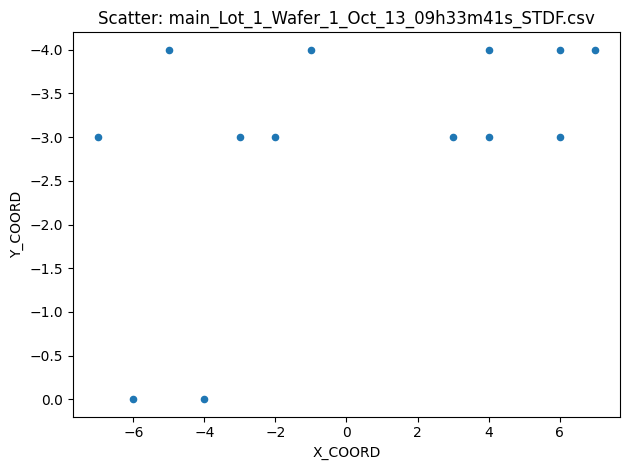


=== main_Lot_1_Wafer_1_Oct_13_09h33m41s_STDF_prr.csv ===

┌────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┬────┐   x=-5 y=-4 ID=1
│    │ -7 │ -6 │ -5 │ -4 │ -3 │ -2 │ -1 │ 0  │ 1  │ 2  │ 3  │ 4  │ 5  │ 6  │ 7  │   x=-1 y=-4 ID=2
├────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┼────┤   x=4 y=-4 ID=3
│  0 │    │ 12 │    │ 13 │    │    │    │    │    │    │    │    │    │    │    │   x=6 y=-4 ID=4
│ -1 │    │    │    │    │    │    │    │    │    │    │    │    │    │    │    │   x=7 y=-4 ID=5
│ -2 │    │    │    │    │    │    │    │    │    │    │    │    │    │    │    │   x=-7 y=-3 ID=6
│ -3 │ 6  │    │    │    │ 7  │ 8  │    │    │    │    │ 9  │ 10 │    │ 11 │    │   x=-3 y=-3 ID=7
│ -4 │    │    │ 1  │    │    │    │ 2  │    │    │    │    │ 3  │    │ 4  │ 5  │   x=-2 y=-3 ID=8
└────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┴────┘   x=3 y=-3 ID=9
                                                      

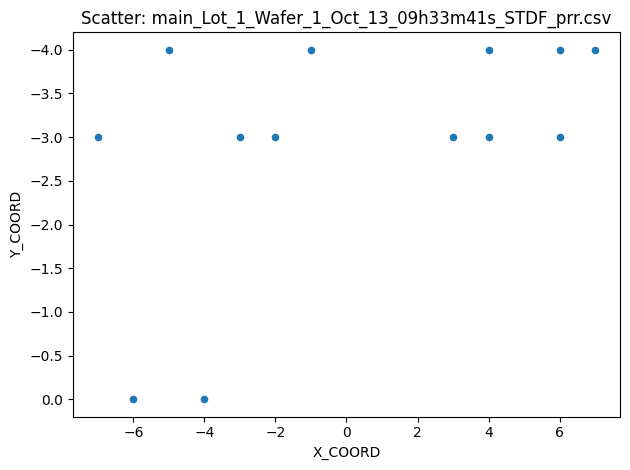

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1) Function to build the grid with complete continuous X-coordinates and Y-axis
def build_grid_with_yaxis(df):
    min_x, max_x = int(df.X_COORD.min()), int(df.X_COORD.max())
    min_y, max_y = int(df.Y_COORD.min()), int(df.Y_COORD.max())
    xs = list(range(min_x, max_x + 1))
    ys = list(range(min_y, max_y + 1))[::-1]

    w_x = max(
        max(len(str(x)) for x in xs),
        df.PART_ID.dropna().astype(str).map(len).max() if not df.PART_ID.dropna().empty else 1
    )
    w_y = max(len(str(min_y)), len(str(max_y)))

    def sep(left, mid, right):
        parts = ['─' * (w_y + 2)] + ['─' * (w_x + 2) for _ in xs]
        return left + mid.join(parts) + right

    top    = sep('┌', '┬', '┐')
    midsep = sep('├', '┼', '┤')
    bot    = sep('└', '┴', '┘')

    header_cells = [' ' * (w_y + 2)] + [f' {x:^{w_x}} ' for x in xs]
    header = '│' + '│'.join(header_cells) + '│'

    lines = [top, header, midsep]
    for y in ys:
        row = [f' {y:>{w_y}} ']
        for x in xs:
            sel = df[(df.X_COORD == x) & (df.Y_COORD == y) & df.PART_ID.notna()]
            cell = str(int(sel.PART_ID.iloc[0])) if not sel.empty else ''
            row.append(f' {cell:^{w_x}} ')
        lines.append('│' + '│'.join(row) + '│')
    lines.append(bot)
    return lines

# 2) Function to list only points that have a PART_ID
def build_list_lines(df):
    lines = []
    for _, r in df.iterrows():
        if pd.notna(r.PART_ID):
            x, y, pid = int(r.X_COORD), int(r.Y_COORD), int(r.PART_ID)
            lines.append(f"x={x} y={y} ID={pid}")
    return lines

# 3) Function to draw scatter plot (no annotations) and both save & show
def draw_scatter(df, output_dir, base_fname):
    fig, ax = plt.subplots()
    x = df.X_COORD.astype(float)
    y = df.Y_COORD.astype(float)
    ax.scatter(x, y, s=20)  # s=20 調整點大小，可自行修改

    ax.set_xlabel('X_COORD')
    ax.set_ylabel('Y_COORD')
    ax.set_title(f'Scatter: {base_fname}')
    ax.invert_yaxis()       # 保持與 ASCII grid 相同的 Y 軸方向

    fig.tight_layout()

    # 1) 存檔到 output 資料夾
    plot_path = os.path.join(output_dir, f"{os.path.splitext(base_fname)[0]}.png")
    fig.savefig(plot_path)

    # 2) 顯示出來
    plt.show()

    # 3) 關閉 figure
    plt.close(fig)

# 4) Main
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}. Please place your CSV files here.")
else:
    for fname in sorted(os.listdir(output_dir)):
        if not fname.lower().endswith('.csv'):
            continue
        path = os.path.join(output_dir, fname)
        try:
            df = pd.read_csv(path)
            # 檢查欄位
            if not all(col in df.columns for col in ['X_COORD','Y_COORD','PART_ID']):
                print(f"Skipping {fname}: 缺少必要欄位。")
                continue

            grid_lines = build_grid_with_yaxis(df)
            list_lines = build_list_lines(df)
            grid_w = max(len(l) for l in grid_lines)

            print(f"\n=== {fname} ===\n")
            total_lines = max(len(grid_lines), len(list_lines))
            for i in range(total_lines):
                left = grid_lines[i] if i < len(grid_lines) else ' ' * grid_w
                right = list_lines[i] if i < len(list_lines) else ''
                print(f"{left}   {right}")
            print()

            # 直接跳出並顯示散佈圖，並存成 PNG
            draw_scatter(df, output_dir, fname)

        except Exception as e:
            print(f"Error processing {fname}: {e}")
